# Loading Extracted Data to Pandas

In [6]:
import pandas as pd

df = pd.read_csv("electricity_demand.csv")
df.head()

,Year,Domestic & Small Commercial,Industrial (Large & Medium),Street Lighting,Rural Electrification,Total Demand(Gwh)
0,2024,4459.1,5515.2,89.9,684.79,10748.99
1,2023,4252.4,5299.8,109.1,659.36,10320.66
2,2022,4291.5,4958.2,94.2,664.47,10008.37
3,2021,4088.6,4728.4,99.6,648.80,9565.40
4,2020,3829.1,4281.0,74.5,611.90,8796.50


# Cleaning and Structuring Data

In [7]:
df.columns = [
    "Year",
    "Domestic",
    "Industrial",
    "Street_Lighting",
    "Rural",
    "Total"
]

In [10]:
df.sample(10)

,Year,Domestic,Industrial,Street_Lighting,Rural,Total
35,1989,729.0,1632.0,14.0,49.00,2424.00
23,2001,1132.8,2167.5,6.5,129.00,3435.80
10,2014,3273.8,3891.5,22.5,478.70,7666.50
0,2024,4459.1,5515.2,89.9,684.79,10748.99
2,2022,4291.5,4958.2,94.2,664.47,10008.37
39,1985,545.0,1354.0,9.0,0.00,1908.00
30,1994,977.0,1955.0,10.0,138.00,3080.00
11,2013,2866.1,3585.3,17.2,426.80,6895.40
26,1998,1212.6,2137.3,10.1,155.10,3515.10
31,1993,927.0,1915.0,13.0,104.00,2959.00


# Demand Analysis
## Visualization of the total demand trend

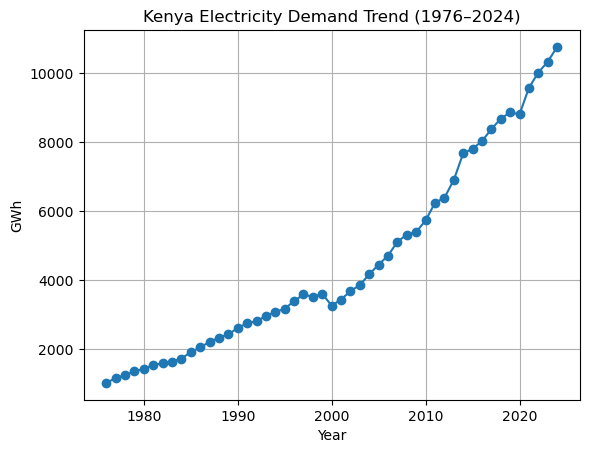

In [15]:
import matplotlib.pyplot as plt

plt.plot(df["Year"], df["Total"], marker='o')
plt.grid(True)
plt.title("Kenya Electricity Demand Trend (1976–2024)")
plt.xlabel("Year")
plt.ylabel("GWh")
plt.show()

## Sector Comparison

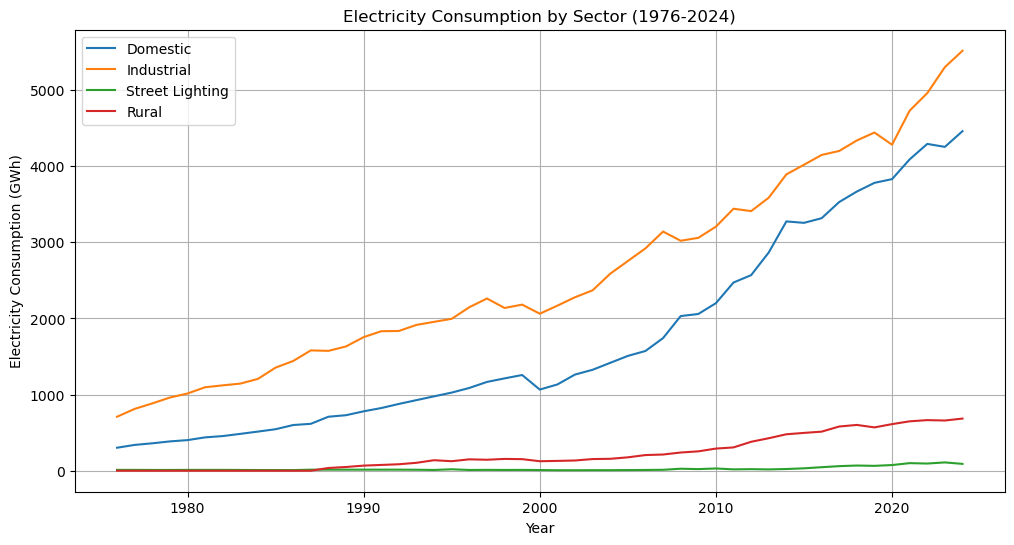

In [20]:
plt.figure(figsize=(12,6))

plt.plot(df['Year'], df['Domestic'], label='Domestic')
plt.plot(df['Year'], df['Industrial'], label='Industrial')
plt.plot(df['Year'], df['Street_Lighting'], label='Street Lighting')
plt.plot(df['Year'], df['Rural'], label='Rural')

plt.xlabel('Year')
plt.ylabel('Electricity Consumption (GWh)')
plt.title('Electricity Consumption by Sector (1976-2024)')
plt.legend()
plt.grid(True)

plt.show()

## Sector Share 2024

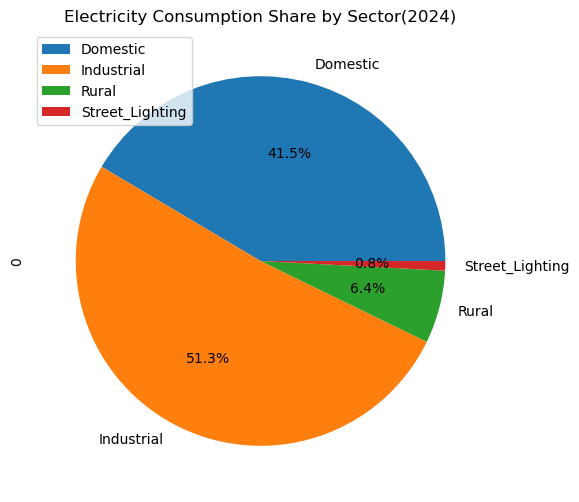

In [21]:
latest = df[df["Year"] == 2024]

latest[["Domestic","Industrial","Rural","Street_Lighting"]].T.plot(kind="pie",autopct="%1.1f%%",figsize=(6,6), subplots=True)
plt.title("Electricity Consumption Share by Sector(2024)")
plt.show()

### Insights

- The industrial sector accounts for the largest share of electricity consumption in 2024, contributing more than half of the total demand.

- Domestic consumption represents the second largest share, indicating significant electricity usage at the household level.

- Rural electricity consumption forms a relatively small portion of the total, highlighting lower access or usage in rural areas compared to urban and industrial regions.

- Street lighting contributes a negligible share to overall electricity demand, making it the smallest consumer among all sectors.

- The dominance of industrial and domestic sectors shows that electricity demand in Kenya is primarily driven by economic activity and residential needs.


- The concentration of electricity consumption in industrial and domestic sectors indicates an uneven distribution of energy usage, which may reflect infrastructure development patterns and urban concentration.

- Increasing the share of rural consumption could be a key indicator of successful rural electrification programs and inclusive energy access.

# Generation and Imports
- The generation and imports table will be loaded using pandas.

In [10]:
gen_df = pd.read_csv("generation_mix.csv")
gen_df.head()

,Year,Hydro,Geothermal,Thermal,Wind,Solar,Imports,Total Supply
0,2020,4232.7,5059.8,754.5,1331.4,88.4,136.7,11603.5
1,2021,3675.0,5037.0,1262.0,1984.8,167.4,288.0,12414.2
2,2022,3039.9,5517.5,1584.9,2143.0,383.7,316.0,12985.0
3,2023,2666.7,6032.1,1305.7,2008.1,491.5,919.3,13423.4
4,2024,3630.7,5551.0,1229.5,1797.7,460.4,1532.6,14201.9


## Cleaning and Structuring Data

In [11]:
gen_df.columns = [
    "Year",
    "Hydro",
    "Geothermal",
    "Thermal",
    "Wind",
    "Solar",
    "Imports",
    "Total_Supply"
]


### Merging the Demand, Generation and Supply Datasets

In [12]:
df = pd.merge(df, gen_df, on="Year")
df.head()

,Year,Domestic,Industrial,Street_Lighting,Rural,Total,Hydro,Geothermal,Thermal,Wind,Solar,Imports,Total_Supply
0,2020,3829.1,4281.0,74.5,611.9,11603.6,4232.7,5059.8,754.5,1331.4,88.4,136.7,11603.5
1,2021,4088.6,4728.4,99.6,648.8,12414.7,3675.0,5037.0,1262.0,1984.8,167.4,288.0,12414.2
2,2022,4291.5,4958.2,94.2,664.5,12985.4,3039.9,5517.5,1584.9,2143.0,383.7,316.0,12985.0
3,2023,4252.4,5299.8,109.1,659.4,13423.6,2666.7,6032.1,1305.7,2008.1,491.5,919.3,13423.4
4,2024,4459.1,5515.2,89.9,684.8,14101.9,3630.7,5551.0,1229.5,1797.7,460.4,1532.6,14201.9


## Analysis
### Energy Mix over Time

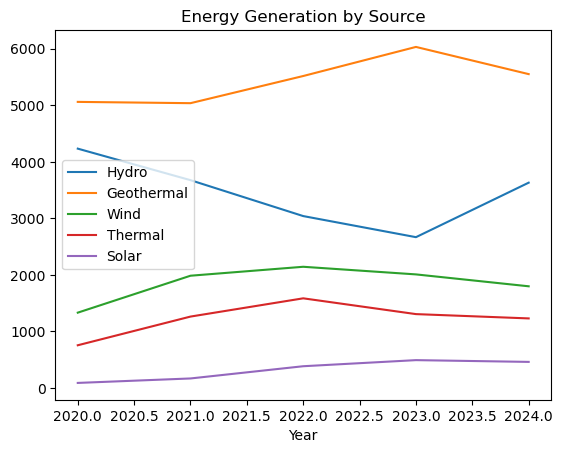

In [13]:
gen_df.set_index("Year")[["Hydro","Geothermal","Wind","Thermal","Solar"]].plot()
plt.title("Energy Generation by Source")
plt.show()

### Imports Trend

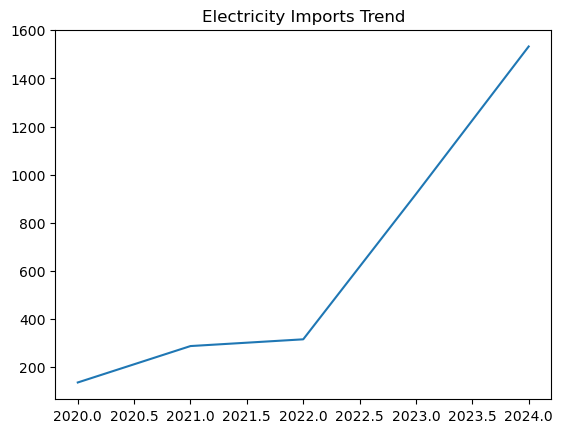

In [14]:
plt.plot(gen_df["Year"], gen_df["Imports"])
plt.title("Electricity Imports Trend")
plt.show()

### Supply vs Demand

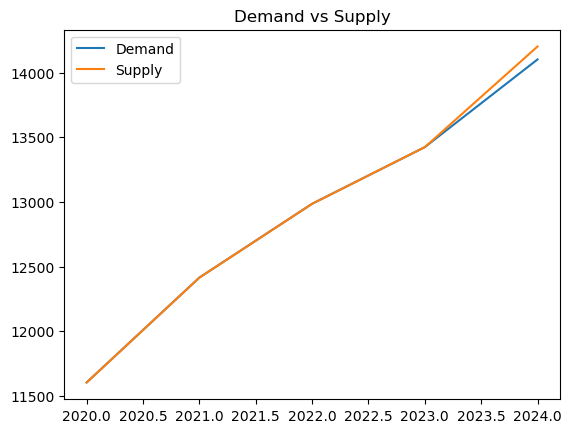

In [15]:
plt.plot(df["Year"], df["Total"], label="Demand")
plt.plot(df["Year"], df["Total_Supply"], label="Supply")
plt.legend()
plt.title("Demand vs Supply")
plt.show()

## Insights
- Geothermal dominates Kenya’s energy mix a good indicator for reliability on renewable energy.
- Imports increasing over time shows regional dependency growing.
- Supply closely tracks demand an indicator of a tight grid balance.